# Phân tích bottleneck của CPU Non-Local Means

Notebook này đo runtime của từng stage trong một image-processing pipeline có sử dụng
**CPU Non-Local Means (NLM)**.

## Mục tiêu

- Tách pipeline thành các stage độc lập.
- Đo runtime của từng stage.
- Tính tỷ lệ runtime của CPU NLM trong toàn bộ experimental flow.
- Tính tỷ lệ runtime của CPU NLM trong actual denoising flow.
- Xác định stage chiếm phần lớn thời gian thực thi.
- Tạo bằng chứng thực nghiệm cho việc tăng tốc NLM bằng CUDA.

## Giới hạn của kết luận

Notebook này sử dụng phiên bản `CPU NLM naive` bằng Python.

Do đó, kết luận chính xác là:

> CPU NLM naive là bottleneck trong pipeline thử nghiệm hiện tại.

Kết quả không khẳng định rằng mọi CPU NLM implementation đã được tối ưu đều có
cùng runtime hoặc cùng mức bottleneck.

In [ ]:
import os
import time
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from google.colab import files
from skimage.metrics import (
    peak_signal_noise_ratio,
    structural_similarity,
)

## 1. Chọn input image

Notebook nhận một ảnh thực tế do người dùng tải lên.

Ảnh được dùng để xây dựng một pipeline gồm:

1. JPEG read and decode;
2. color conversion;
3. resize hoặc center crop;
4. grayscale conversion;
5. float32 normalization;
6. synthetic Gaussian-noise generation;
7. CPU NLM denoising;
8. PSNR và SSIM evaluation;
9. chuyển output về `uint8`;
10. PNG encoding and saving.

Việc sử dụng ảnh thực tế giúp phép đo phản ánh một workflow gần với ứng dụng hơn
so với chỉ chạy NLM trên một NumPy array được tạo sẵn.

In [ ]:
uploaded = files.upload()

if not uploaded:
    raise RuntimeError("No image was uploaded.")

IMAGE_PATH = next(iter(uploaded.keys()))

print(f"Uploaded image: {IMAGE_PATH}")

Saving 4ef7be51-2410-4fb0-83c6-890a5e026fba.jfif to 4ef7be51-2410-4fb0-83c6-890a5e026fba.jfif
Uploaded image: 4ef7be51-2410-4fb0-83c6-890a5e026fba.jfif


## 2. Cấu hình thí nghiệm

Các tham số chính:

- Target image size: `128 × 128`.
- Patch size: `3 × 3`.
- Search window: `7 × 7`.
- Filtering parameter `h`: `0.12`.
- Gaussian-noise sigma: `0.08`.
- Random seed: `42`.

Kích thước ảnh được cố định để các lần chạy có cùng workload.

Với cấu hình này, mỗi output pixel phải xét:

```text
7 × 7 = 49 candidate patches

In [ ]:
TARGET_SIZE = 128

PATCH_SIZE = 3
SEARCH_WINDOW_SIZE = 7
FILTER_H = 0.12

NOISE_SIGMA = 0.08
RANDOM_SEED = 42

RESIZE_MODE = "resize"
# Chọn:
# "resize"      → co toàn bộ ảnh về 128×128
# "center_crop" → crop vuông ở giữa rồi resize về 128×128

OUTPUT_DIR = Path("nlm_pipeline_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

if PATCH_SIZE % 2 == 0:
    raise ValueError("PATCH_SIZE must be odd.")

if SEARCH_WINDOW_SIZE % 2 == 0:
    raise ValueError("SEARCH_WINDOW_SIZE must be odd.")

if SEARCH_WINDOW_SIZE < PATCH_SIZE:
    raise ValueError(
        "SEARCH_WINDOW_SIZE must be greater than or equal to PATCH_SIZE."
    )

print("Configuration")
print("-" * 50)
print(f"Target size:         {TARGET_SIZE} × {TARGET_SIZE}")
print(f"Patch size:          {PATCH_SIZE} × {PATCH_SIZE}")
print(
    f"Search window size:  "
    f"{SEARCH_WINDOW_SIZE} × {SEARCH_WINDOW_SIZE}"
)
print(f"Filtering h:         {FILTER_H}")
print(f"Noise sigma:         {NOISE_SIGMA}")
print(f"Resize mode:         {RESIZE_MODE}")

Configuration
--------------------------------------------------
Target size:         128 × 128
Patch size:          3 × 3
Search window size:  7 × 7
Filtering h:         0.12
Noise sigma:         0.08
Resize mode:         resize


## 3. Tiền xử lý kích thước ảnh

Hàm `resize_or_center_crop` chuẩn hóa input về một ảnh vuông có kích thước cố định.

Hai chế độ được hỗ trợ:

- `resize`: co toàn bộ ảnh về target size;
- `center_crop`: crop vùng vuông ở giữa rồi resize.

Stage này được đo riêng để xác định chi phí preprocessing so với CPU NLM.

In [ ]:
def resize_or_center_crop(
    image_rgb: np.ndarray,
    target_size: int,
    mode: str = "resize",
) -> np.ndarray:
    """
    Resize the full image or center-crop it to a square before resizing.
    """

    if mode == "resize":
        return cv2.resize(
            image_rgb,
            (target_size, target_size),
            interpolation=cv2.INTER_AREA,
        )

    if mode == "center_crop":
        height, width = image_rgb.shape[:2]

        crop_size = min(height, width)

        start_y = (height - crop_size) // 2
        start_x = (width - crop_size) // 2

        cropped = image_rgb[
            start_y:start_y + crop_size,
            start_x:start_x + crop_size,
        ]

        return cv2.resize(
            cropped,
            (target_size, target_size),
            interpolation=cv2.INTER_AREA,
        )

    raise ValueError(
        "mode must be either 'resize' or 'center_crop'."
    )

In [ ]:
def nlm_cpu_naive(
    image: np.ndarray,
    patch_size: int = 3,
    search_window_size: int = 7,
    h: float = 0.12,
) -> np.ndarray:
    """
    Naive grayscale CPU implementation of Non-Local Means.

    Parameters
    ----------
    image:
        2D float32 grayscale image in [0, 1].
    patch_size:
        Odd reference/candidate patch size.
    search_window_size:
        Odd search-window size.
    h:
        Filtering strength.

    Returns
    -------
    np.ndarray
        Denoised float32 image in [0, 1].
    """

    if image.ndim != 2:
        raise ValueError("The CPU NLM implementation expects a grayscale image.")

    if patch_size % 2 == 0:
        raise ValueError("patch_size must be odd.")

    if search_window_size % 2 == 0:
        raise ValueError("search_window_size must be odd.")

    if h <= 0:
        raise ValueError("h must be positive.")

    height, width = image.shape

    patch_radius = patch_size // 2
    search_radius = search_window_size // 2

    padding_radius = patch_radius + search_radius

    padded = np.pad(
        image,
        pad_width=padding_radius,
        mode="reflect",
    )

    output = np.zeros_like(image, dtype=np.float32)

    h_squared = h * h

    for output_y in range(height):
        for output_x in range(width):
            center_y = output_y + padding_radius
            center_x = output_x + padding_radius

            reference_patch = padded[
                center_y - patch_radius:
                center_y + patch_radius + 1,
                center_x - patch_radius:
                center_x + patch_radius + 1,
            ]

            weighted_sum = 0.0
            total_weight = 0.0

            for offset_y in range(
                -search_radius,
                search_radius + 1,
            ):
                for offset_x in range(
                    -search_radius,
                    search_radius + 1,
                ):
                    candidate_y = center_y + offset_y
                    candidate_x = center_x + offset_x

                    candidate_patch = padded[
                        candidate_y - patch_radius:
                        candidate_y + patch_radius + 1,
                        candidate_x - patch_radius:
                        candidate_x + patch_radius + 1,
                    ]

                    difference = (
                        reference_patch - candidate_patch
                    )

                    patch_distance = np.mean(
                        difference * difference
                    )

                    weight = np.exp(
                        -patch_distance / h_squared
                    )

                    candidate_center_pixel = padded[
                        candidate_y,
                        candidate_x,
                    ]

                    weighted_sum += (
                        weight * candidate_center_pixel
                    )

                    total_weight += weight

            output[output_y, output_x] = (
                weighted_sum / total_weight
            )

    return np.clip(output, 0.0, 1.0)

In [ ]:
def run_full_image_pipeline(
    image_path: str,
    target_size: int = 128,
    resize_mode: str = "resize",
    noise_sigma: float = 0.08,
    patch_size: int = 3,
    search_window_size: int = 7,
    h: float = 0.12,
    random_seed: int = 42,
    output_directory: str = "nlm_pipeline_outputs",
):
    """
    Run and profile a complete image-processing experiment.

    The function reports:
    - Complete experimental runtime
    - Actual denoising-flow runtime
    - Runtime of every individual stage
    """

    timings = {}

    output_path = Path(output_directory)
    output_path.mkdir(parents=True, exist_ok=True)

    # ---------------------------------------------------------
    # Stage 1: Read and decode JPEG
    # ---------------------------------------------------------
    start = time.perf_counter()

    image_bgr = cv2.imread(
        image_path,
        cv2.IMREAD_COLOR,
    )

    timings["1. JPEG read and decode"] = (
        time.perf_counter() - start
    )

    if image_bgr is None:
        raise FileNotFoundError(
            f"Could not read image: {image_path}"
        )

    # ---------------------------------------------------------
    # Stage 2: Convert BGR to RGB
    # ---------------------------------------------------------
    start = time.perf_counter()

    image_rgb = cv2.cvtColor(
        image_bgr,
        cv2.COLOR_BGR2RGB,
    )

    timings["2. BGR to RGB"] = (
        time.perf_counter() - start
    )

    # ---------------------------------------------------------
    # Stage 3: Resize or crop
    # ---------------------------------------------------------
    start = time.perf_counter()

    resized_rgb = resize_or_center_crop(
        image_rgb,
        target_size=target_size,
        mode=resize_mode,
    )

    timings["3. Resize or crop"] = (
        time.perf_counter() - start
    )

    # ---------------------------------------------------------
    # Stage 4: Convert RGB to grayscale
    # ---------------------------------------------------------
    start = time.perf_counter()

    grayscale_uint8 = cv2.cvtColor(
        resized_rgb,
        cv2.COLOR_RGB2GRAY,
    )

    timings["4. RGB to grayscale"] = (
        time.perf_counter() - start
    )

    # ---------------------------------------------------------
    # Stage 5: Normalize to float32 [0, 1]
    # ---------------------------------------------------------
    start = time.perf_counter()

    clean_float = (
        grayscale_uint8.astype(np.float32) / 255.0
    )

    timings["5. Float32 normalization"] = (
        time.perf_counter() - start
    )

    # ---------------------------------------------------------
    # Stage 6: Generate Gaussian noise
    # Experimental-data preparation only
    # ---------------------------------------------------------
    start = time.perf_counter()

    rng = np.random.default_rng(random_seed)

    noise = rng.normal(
        loc=0.0,
        scale=noise_sigma,
        size=clean_float.shape,
    ).astype(np.float32)

    noisy_float = np.clip(
        clean_float + noise,
        0.0,
        1.0,
    ).astype(np.float32)

    timings["6. Gaussian-noise generation"] = (
        time.perf_counter() - start
    )

    # ---------------------------------------------------------
    # Stage 7: CPU NLM denoising
    # ---------------------------------------------------------
    start = time.perf_counter()

    denoised_float = nlm_cpu_naive(
        noisy_float,
        patch_size=patch_size,
        search_window_size=search_window_size,
        h=h,
    )

    timings["7. CPU NLM denoising"] = (
        time.perf_counter() - start
    )

    # ---------------------------------------------------------
    # Stage 8: PSNR and SSIM evaluation
    # Experimental evaluation only
    # ---------------------------------------------------------
    start = time.perf_counter()

    noisy_psnr = peak_signal_noise_ratio(
        clean_float,
        noisy_float,
        data_range=1.0,
    )

    denoised_psnr = peak_signal_noise_ratio(
        clean_float,
        denoised_float,
        data_range=1.0,
    )

    noisy_ssim = structural_similarity(
        clean_float,
        noisy_float,
        data_range=1.0,
    )

    denoised_ssim = structural_similarity(
        clean_float,
        denoised_float,
        data_range=1.0,
    )

    timings["8. PSNR and SSIM evaluation"] = (
        time.perf_counter() - start
    )

    # ---------------------------------------------------------
    # Stage 9: Convert float32 result to uint8
    # ---------------------------------------------------------
    start = time.perf_counter()

    noisy_uint8 = np.clip(
        noisy_float * 255.0,
        0,
        255,
    ).astype(np.uint8)

    denoised_uint8 = np.clip(
        denoised_float * 255.0,
        0,
        255,
    ).astype(np.uint8)

    timings["9. Float32 to uint8"] = (
        time.perf_counter() - start
    )

    # ---------------------------------------------------------
    # Stage 10: Encode and save PNG outputs
    # ---------------------------------------------------------
    start = time.perf_counter()

    clean_output_file = (
        output_path / "clean_grayscale.png"
    )
    noisy_output_file = (
        output_path / "noisy_grayscale.png"
    )
    denoised_output_file = (
        output_path / "denoised_nlm.png"
    )

    clean_saved = cv2.imwrite(
        str(clean_output_file),
        grayscale_uint8,
    )

    noisy_saved = cv2.imwrite(
        str(noisy_output_file),
        noisy_uint8,
    )

    denoised_saved = cv2.imwrite(
        str(denoised_output_file),
        denoised_uint8,
    )

    timings["10. PNG encoding and saving"] = (
        time.perf_counter() - start
    )

    if not all(
        [clean_saved, noisy_saved, denoised_saved]
    ):
        raise IOError(
            "One or more output images could not be saved."
        )

    # ---------------------------------------------------------
    # Runtime scopes
    # ---------------------------------------------------------

    experimental_total = sum(timings.values())

    # Actual denoising pipeline excludes:
    # - synthetic-noise generation
    # - PSNR/SSIM evaluation
    denoising_stage_names = [
        "1. JPEG read and decode",
        "2. BGR to RGB",
        "3. Resize or crop",
        "4. RGB to grayscale",
        "5. Float32 normalization",
        "7. CPU NLM denoising",
        "9. Float32 to uint8",
        "10. PNG encoding and saving",
    ]

    denoising_flow_total = sum(
        timings[name]
        for name in denoising_stage_names
    )

    experimental_rows = []

    for stage_name, runtime in timings.items():
        experimental_rows.append(
            {
                "Stage": stage_name,
                "Runtime (s)": runtime,
                "Experimental flow (%)": (
                    runtime / experimental_total * 100.0
                ),
                "Included in denoising flow": (
                    stage_name in denoising_stage_names
                ),
            }
        )

    runtime_table = pd.DataFrame(
        experimental_rows
    )

    runtime_table[
        "Denoising flow (%)"
    ] = runtime_table.apply(
        lambda row: (
            row["Runtime (s)"]
            / denoising_flow_total
            * 100.0
        )
        if row["Included in denoising flow"]
        else np.nan,
        axis=1,
    )

    nlm_runtime = timings[
        "7. CPU NLM denoising"
    ]

    results = {
        "original_rgb": image_rgb,
        "resized_rgb": resized_rgb,
        "clean_float": clean_float,
        "noisy_float": noisy_float,
        "denoised_float": denoised_float,
        "runtime_table": runtime_table,
        "timings": timings,
        "experimental_total": experimental_total,
        "denoising_flow_total": denoising_flow_total,
        "nlm_experimental_percentage": (
            nlm_runtime
            / experimental_total
            * 100.0
        ),
        "nlm_denoising_flow_percentage": (
            nlm_runtime
            / denoising_flow_total
            * 100.0
        ),
        "noisy_psnr": noisy_psnr,
        "denoised_psnr": denoised_psnr,
        "noisy_ssim": noisy_ssim,
        "denoised_ssim": denoised_ssim,
        "output_files": {
            "clean": str(clean_output_file),
            "noisy": str(noisy_output_file),
            "denoised": str(denoised_output_file),
        },
    }

    return results

In [ ]:
pipeline_result = run_full_image_pipeline(
    image_path=IMAGE_PATH,
    target_size=TARGET_SIZE,
    resize_mode=RESIZE_MODE,
    noise_sigma=NOISE_SIGMA,
    patch_size=PATCH_SIZE,
    search_window_size=SEARCH_WINDOW_SIZE,
    h=FILTER_H,
    random_seed=RANDOM_SEED,
    output_directory=str(OUTPUT_DIR),
)

In [ ]:
runtime_table = pipeline_result[
    "runtime_table"
].copy()

pd.set_option(
    "display.float_format",
    lambda value: f"{value:.6f}",
)

display(runtime_table)

,Stage,Runtime (s),Experimental flow (%),Included in denoising flow,Denoising flow (%)
0,1. JPEG read and decode,0.053316,0.377991,True,0.378095
1,2. BGR to RGB,0.010816,0.076686,True,0.076707
2,3. Resize or crop,0.009893,0.070141,True,0.070161
3,4. RGB to grayscale,0.003675,0.026057,True,0.026064
4,5. Float32 normalization,0.000097,0.000687,True,0.000687
5,6. Gaussian-noise generation,0.000708,0.005017,False,NaN
6,7. CPU NLM denoising,14.016554,99.372992,True,99.400399
7,8. PSNR and SSIM evaluation,0.003181,0.022556,False,NaN
8,9. Float32 to uint8,0.000119,0.000840,True,0.000840
9,10. PNG encoding and saving,0.006634,0.047034,True,0.047047


In [ ]:
print("Runtime summary")
print("-" * 60)

print(
    "Complete experimental flow: "
    f"{pipeline_result['experimental_total']:.6f} s"
)

print(
    "Actual denoising flow:       "
    f"{pipeline_result['denoising_flow_total']:.6f} s"
)

print(
    "NLM share of experimental flow: "
    f"{pipeline_result['nlm_experimental_percentage']:.2f}%"
)

print(
    "NLM share of denoising flow:    "
    f"{pipeline_result['nlm_denoising_flow_percentage']:.2f}%"
)

print()
print("Quality summary")
print("-" * 60)

print(
    f"Noisy PSNR:       "
    f"{pipeline_result['noisy_psnr']:.2f} dB"
)

print(
    f"Denoised PSNR:    "
    f"{pipeline_result['denoised_psnr']:.2f} dB"
)

print(
    f"PSNR improvement: "
    f"{pipeline_result['denoised_psnr'] - pipeline_result['noisy_psnr']:.2f} dB"
)

print(
    f"Noisy SSIM:       "
    f"{pipeline_result['noisy_ssim']:.4f}"
)

print(
    f"Denoised SSIM:    "
    f"{pipeline_result['denoised_ssim']:.4f}"
)

Runtime summary
------------------------------------------------------------
Complete experimental flow: 14.104994 s
Actual denoising flow:       14.101105 s
NLM share of experimental flow: 99.37%
NLM share of denoising flow:    99.40%

Quality summary
------------------------------------------------------------
Noisy PSNR:       22.33 dB
Denoised PSNR:    26.24 dB
PSNR improvement: 3.91 dB
Noisy SSIM:       0.7461
Denoised SSIM:    0.8641


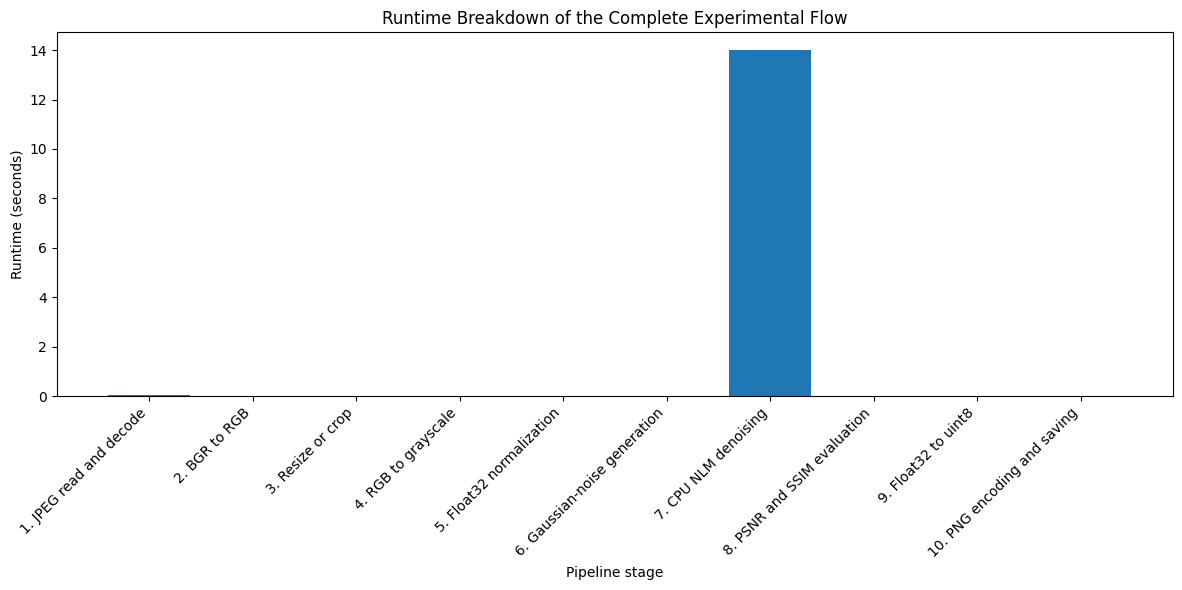

In [ ]:
experimental_profile = runtime_table.copy()

plt.figure(figsize=(12, 6))

plt.bar(
    experimental_profile["Stage"],
    experimental_profile["Runtime (s)"],
)

plt.xlabel("Pipeline stage")
plt.ylabel("Runtime (seconds)")
plt.title(
    "Runtime Breakdown of the Complete Experimental Flow"
)

plt.xticks(
    rotation=45,
    ha="right",
)

plt.tight_layout()
plt.show()

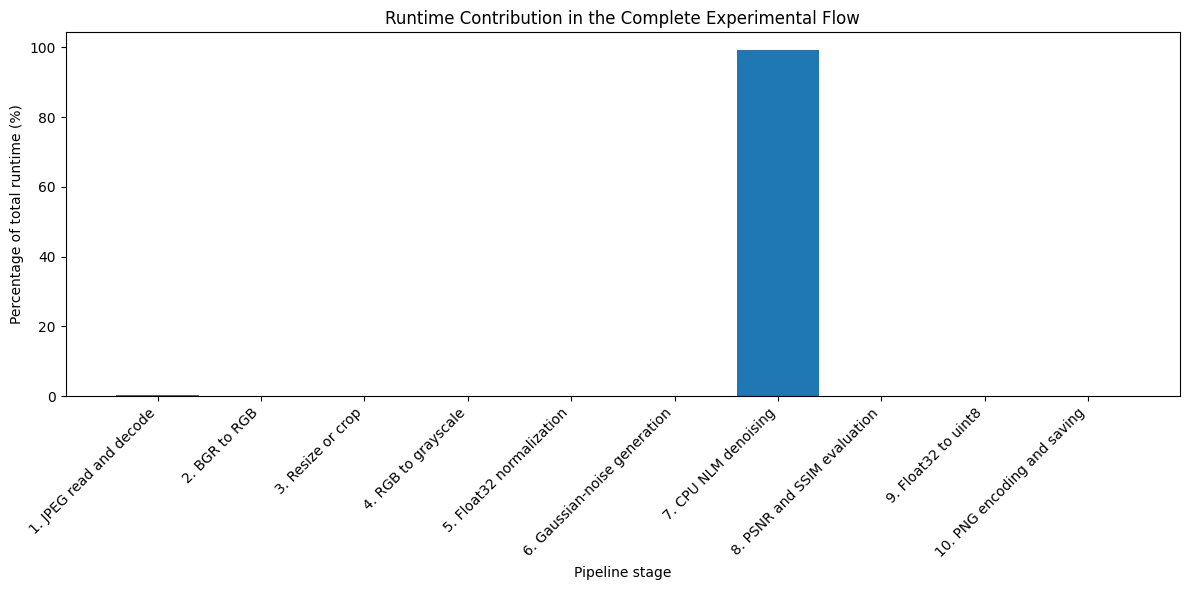

In [ ]:
plt.figure(figsize=(12, 6))

plt.bar(
    experimental_profile["Stage"],
    experimental_profile[
        "Experimental flow (%)"
    ],
)

plt.xlabel("Pipeline stage")
plt.ylabel("Percentage of total runtime (%)")
plt.title(
    "Runtime Contribution in the Complete Experimental Flow"
)

plt.xticks(
    rotation=45,
    ha="right",
)

plt.tight_layout()
plt.show()

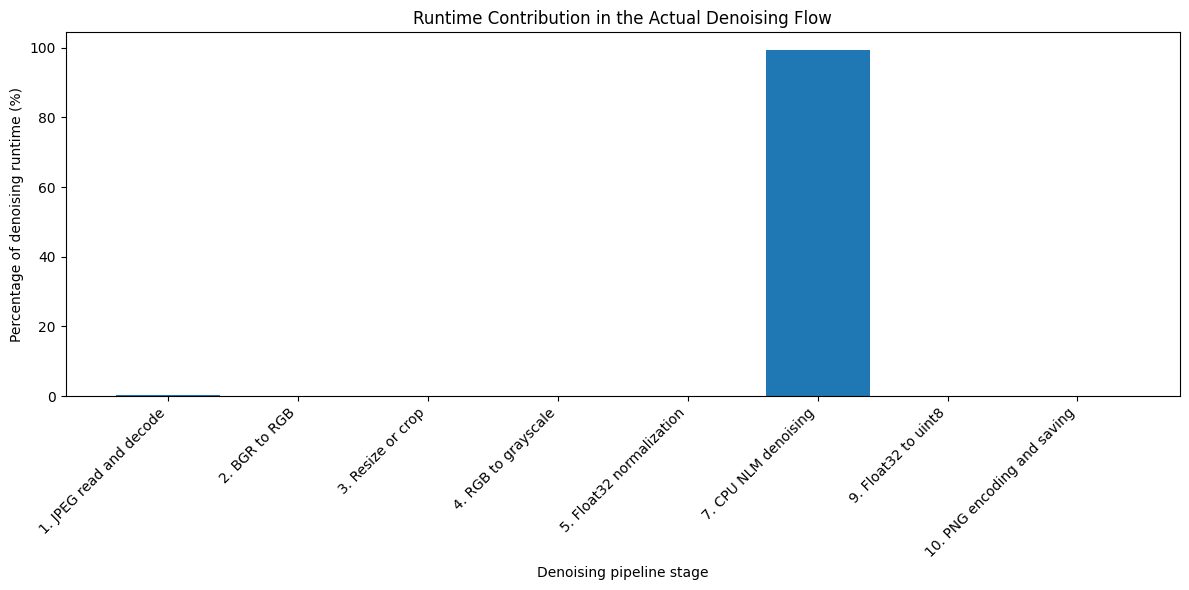

In [ ]:
denoising_profile = runtime_table[
    runtime_table[
        "Included in denoising flow"
    ]
].copy()

plt.figure(figsize=(12, 6))

plt.bar(
    denoising_profile["Stage"],
    denoising_profile[
        "Denoising flow (%)"
    ],
)

plt.xlabel("Denoising pipeline stage")
plt.ylabel("Percentage of denoising runtime (%)")
plt.title(
    "Runtime Contribution in the Actual Denoising Flow"
)

plt.xticks(
    rotation=45,
    ha="right",
)

plt.tight_layout()
plt.show()

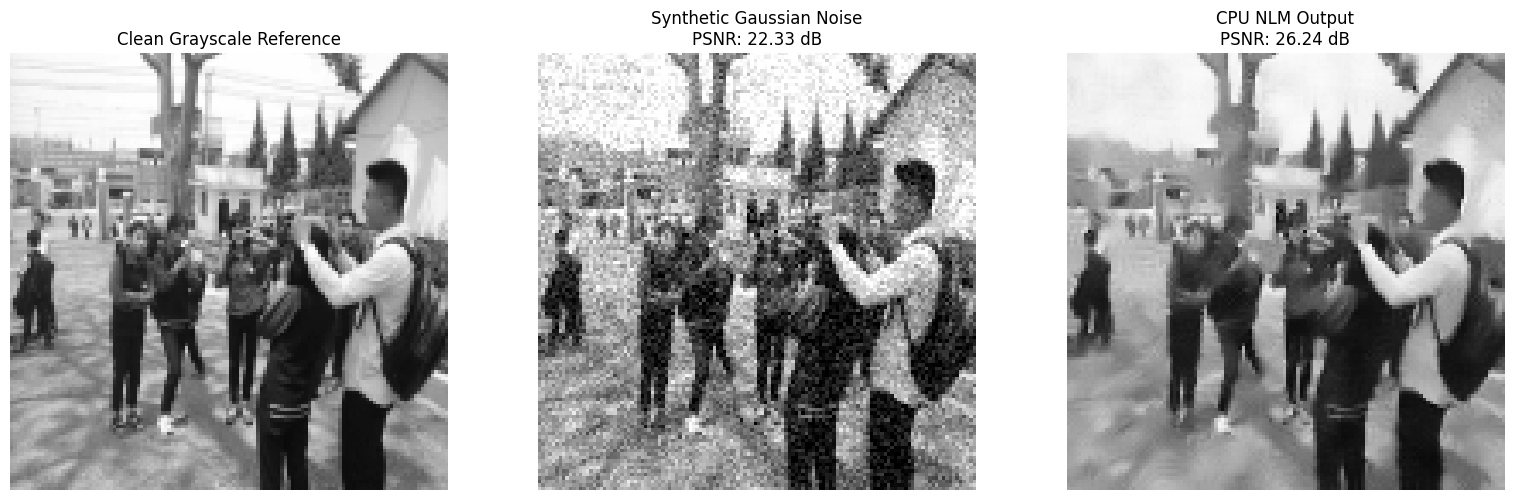

In [ ]:
clean_image = pipeline_result["clean_float"]
noisy_image = pipeline_result["noisy_float"]
denoised_image = pipeline_result[
    "denoised_float"
]

plt.figure(figsize=(16, 5))

plt.subplot(1, 3, 1)
plt.imshow(
    clean_image,
    cmap="gray",
    vmin=0,
    vmax=1,
)
plt.title("Clean Grayscale Reference")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(
    noisy_image,
    cmap="gray",
    vmin=0,
    vmax=1,
)
plt.title(
    "Synthetic Gaussian Noise\n"
    f"PSNR: {pipeline_result['noisy_psnr']:.2f} dB"
)
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(
    denoised_image,
    cmap="gray",
    vmin=0,
    vmax=1,
)
plt.title(
    "CPU NLM Output\n"
    f"PSNR: {pipeline_result['denoised_psnr']:.2f} dB"
)
plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
print("Saved output files:")

for name, file_path in pipeline_result[
    "output_files"
].items():
    print(f"{name}: {file_path}")

Saved output files:
clean: nlm_pipeline_outputs/clean_grayscale.png
noisy: nlm_pipeline_outputs/noisy_grayscale.png
denoised: nlm_pipeline_outputs/denoised_nlm.png
